# 02 — RCAEval Dataset Exploration

This notebook explores the RCAEval benchmark datasets (RE1, RE2, RE3) downloaded from Zenodo. RCAEval provides 736 labeled root cause analysis cases across three microservice systems: Online Boutique (OB), Sock Shop (SS), and Train Ticket (TT).

**Goals:**
- Understand the directory structure and file formats per variant
- Map fault type and root cause service distributions
- Analyze metric column naming differences across systems
- Identify normalization requirements for the Phase 3 `RCAEvalDataAdapter`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

RCAEVAL_DIR = Path("../data/RCAEval")
VARIANTS = ["re1", "re2", "re3"]
SYSTEMS = {"OB": "Online Boutique", "SS": "Sock Shop", "TT": "Train Ticket"}

## Case Inventory

Build a comprehensive inventory of all cases across all variants and systems.

In [2]:
cases = []

for variant in VARIANTS:
    variant_dir = RCAEVAL_DIR / variant
    if not variant_dir.exists():
        print(f"WARNING: {variant_dir} not found")
        continue

    for system_dir in sorted(variant_dir.iterdir()):
        if not system_dir.is_dir():
            continue
        system_code = system_dir.name.split("-")[-1]  # e.g., "RE1-OB" -> "OB"

        for fault_dir in sorted(system_dir.iterdir()):
            if not fault_dir.is_dir():
                continue
            # Parse fault directory name: e.g., "adservice_cpu" -> service=adservice, fault=cpu
            parts = fault_dir.name.rsplit("_", 1)
            if len(parts) == 2:
                service, fault_type = parts
            else:
                service, fault_type = fault_dir.name, "unknown"

            for run_dir in sorted(fault_dir.iterdir()):
                if not run_dir.is_dir():
                    continue
                inject_time_file = run_dir / "inject_time.txt"
                if not inject_time_file.exists():
                    continue

                inject_time = inject_time_file.read_text().strip()
                files_present = [f.name for f in run_dir.iterdir() if f.is_file()]

                cases.append({
                    "variant": variant.upper(),
                    "system": system_code,
                    "service": service,
                    "fault_type": fault_type,
                    "run": run_dir.name,
                    "inject_time": inject_time,
                    "has_data_csv": "data.csv" in files_present,
                    "has_metrics_csv": "metrics.csv" in files_present,
                    "has_logs": "logs.csv" in files_present,
                    "has_traces": "traces.csv" in files_present,
                    "path": str(run_dir),
                })

case_df = pd.DataFrame(cases)
print(f"Total cases: {len(case_df)}")
print()
print("Cases per variant:")
print(case_df.groupby("variant").size().to_string())
print()
print("Cases per variant × system:")
print(case_df.groupby(["variant", "system"]).size().unstack(fill_value=0))

Total cases: 736

Cases per variant:
variant
RE1    375
RE2    271
RE3     90

Cases per variant × system:
system    OB   SS   TT
variant               
RE1      125  125  125
RE2       91   90   90
RE3       30   30   30


## Directory Structure Samples

Inspect the file contents from one representative case per variant.

In [3]:
for variant in VARIANTS:
    sample = case_df[case_df["variant"] == variant.upper()].iloc[0]
    case_path = Path(sample["path"])

    print(f"\n{'='*60}")
    print(f"{variant.upper()} Sample: {case_path.relative_to(RCAEVAL_DIR)}")
    print(f"{'='*60}")
    print(f"Service: {sample['service']}, Fault: {sample['fault_type']}, Run: {sample['run']}")
    print(f"Inject time: {sample['inject_time']}")
    print(f"Files: {sorted(f.name for f in case_path.iterdir() if f.is_file())}")

    # Show metric data columns
    if sample["has_data_csv"]:
        data_file = case_path / "data.csv"
        df_sample = pd.read_csv(data_file, nrows=3)
        print(f"\ndata.csv: {len(df_sample.columns)} columns, sample:")
        print(f"  Columns: {list(df_sample.columns[:10])}...")
        print(df_sample.head(2).to_string())

    if sample["has_metrics_csv"]:
        metrics_file = case_path / "metrics.csv"
        df_sample = pd.read_csv(metrics_file, nrows=3)
        print(f"\nmetrics.csv: {len(df_sample.columns)} columns, sample:")
        print(f"  Columns (first 10): {list(df_sample.columns[:10])}...")
        print(df_sample.head(2).to_string())

    if sample["has_logs"]:
        logs_file = case_path / "logs.csv"
        try:
            df_logs = pd.read_csv(logs_file, nrows=3)
            print(f"\nlogs.csv: {len(df_logs.columns)} columns")
            print(f"  Columns: {list(df_logs.columns)}")
        except Exception as e:
            print(f"\nlogs.csv: Error reading — {e}")

    if sample["has_traces"]:
        traces_file = case_path / "traces.csv"
        try:
            df_traces = pd.read_csv(traces_file, nrows=3)
            print(f"\ntraces.csv: {len(df_traces.columns)} columns")
            print(f"  Columns: {list(df_traces.columns)}")
        except Exception as e:
            print(f"\ntraces.csv: Error reading — {e}")


RE1 Sample: re1/RE1-OB/adservice_cpu/1
Service: adservice, Fault: cpu, Run: 1
Inject time: 1685202688
Files: ['data.csv', 'inject_time.txt']

data.csv: 51 columns, sample:
  Columns: ['time', 'adservice_cpu', 'cartservice_cpu', 'checkoutservice_cpu', 'currencyservice_cpu', 'emailservice_cpu', 'frontend_cpu', 'main_cpu', 'paymentservice_cpu', 'productcatalogservice_cpu']...
         time  adservice_cpu  cartservice_cpu  checkoutservice_cpu  currencyservice_cpu  emailservice_cpu  frontend_cpu  main_cpu  paymentservice_cpu  productcatalogservice_cpu  recommendationservice_cpu  redis_cpu  shippingservice_cpu  adservice_mem  cartservice_mem  checkoutservice_mem  currencyservice_mem  emailservice_mem  frontend_mem    main_mem  paymentservice_mem  productcatalogservice_mem  recommendationservice_mem  redis_mem  shippingservice_mem  PassthroughCluster_load  adservice_load  cartservice_load  checkoutservice_load  currencyservice_load  emailservice_load  frontend_load  frontend-external_load  p

## Fault Type Distribution

Distribution of fault types across all variants and systems.

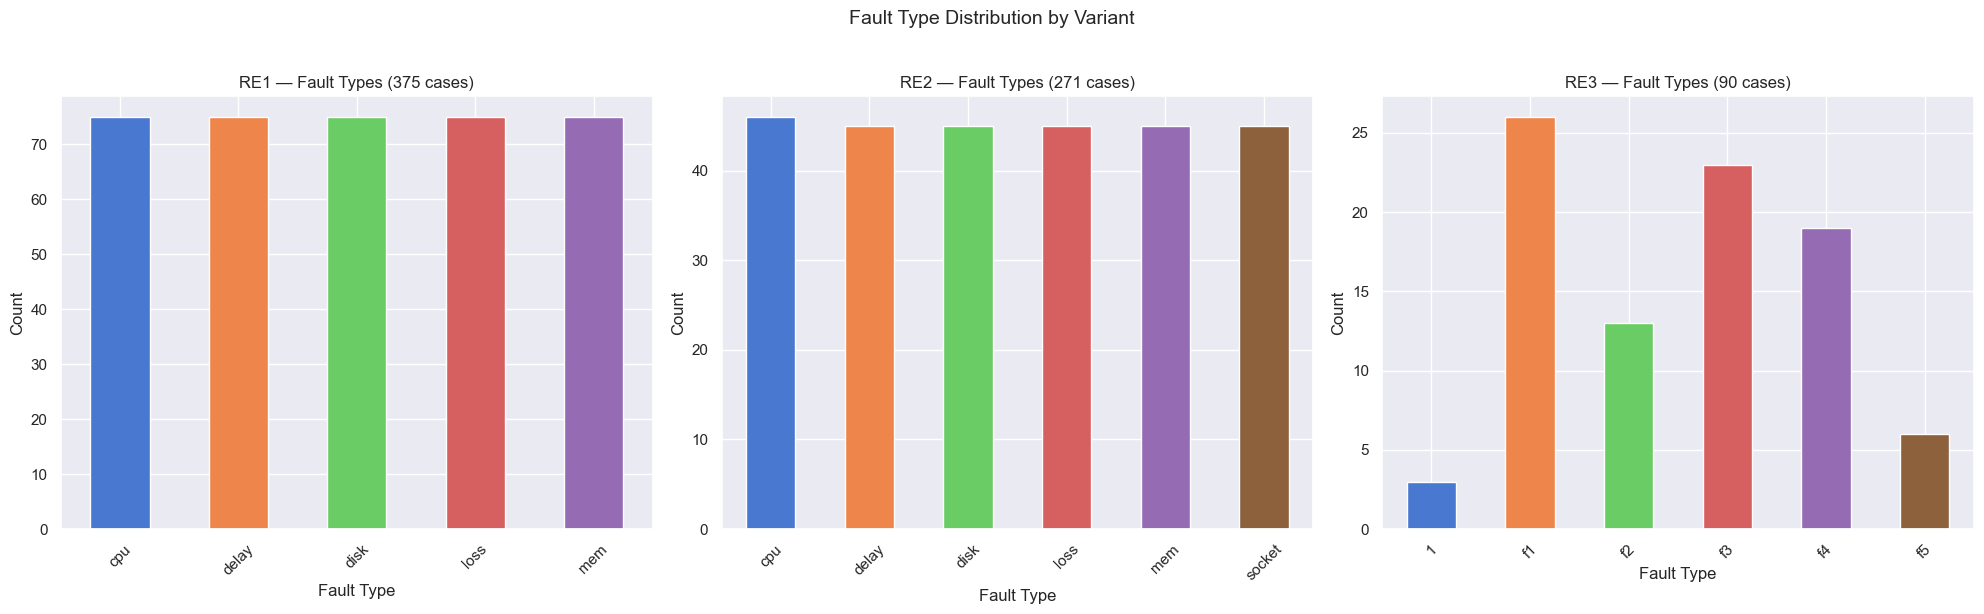


Fault types per variant:
fault_type  1  cpu  delay  disk  f1  f2  f3  f4  f5  loss  mem  socket
variant                                                               
RE1         0   75     75    75   0   0   0   0   0    75   75       0
RE2         0   46     45    45   0   0   0   0   0    45   45      45
RE3         3    0      0     0  26  13  23  19   6     0    0       0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, variant in zip(axes, ["RE1", "RE2", "RE3"]):
    vdf = case_df[case_df["variant"] == variant]
    fault_counts = vdf["fault_type"].value_counts().sort_index()
    fault_counts.plot.bar(ax=ax, color=sns.color_palette("muted", len(fault_counts)))
    ax.set_title(f"{variant} — Fault Types ({len(vdf)} cases)", fontsize=12)
    ax.set_xlabel("Fault Type")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Fault Type Distribution by Variant", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("\nFault types per variant:")
fault_summary = case_df.groupby(["variant", "fault_type"]).size().unstack(fill_value=0)
print(fault_summary.to_string())

## Root Cause Service Breakdown

Distribution of target services (the services where faults are injected). This shows which services are most frequently targeted.

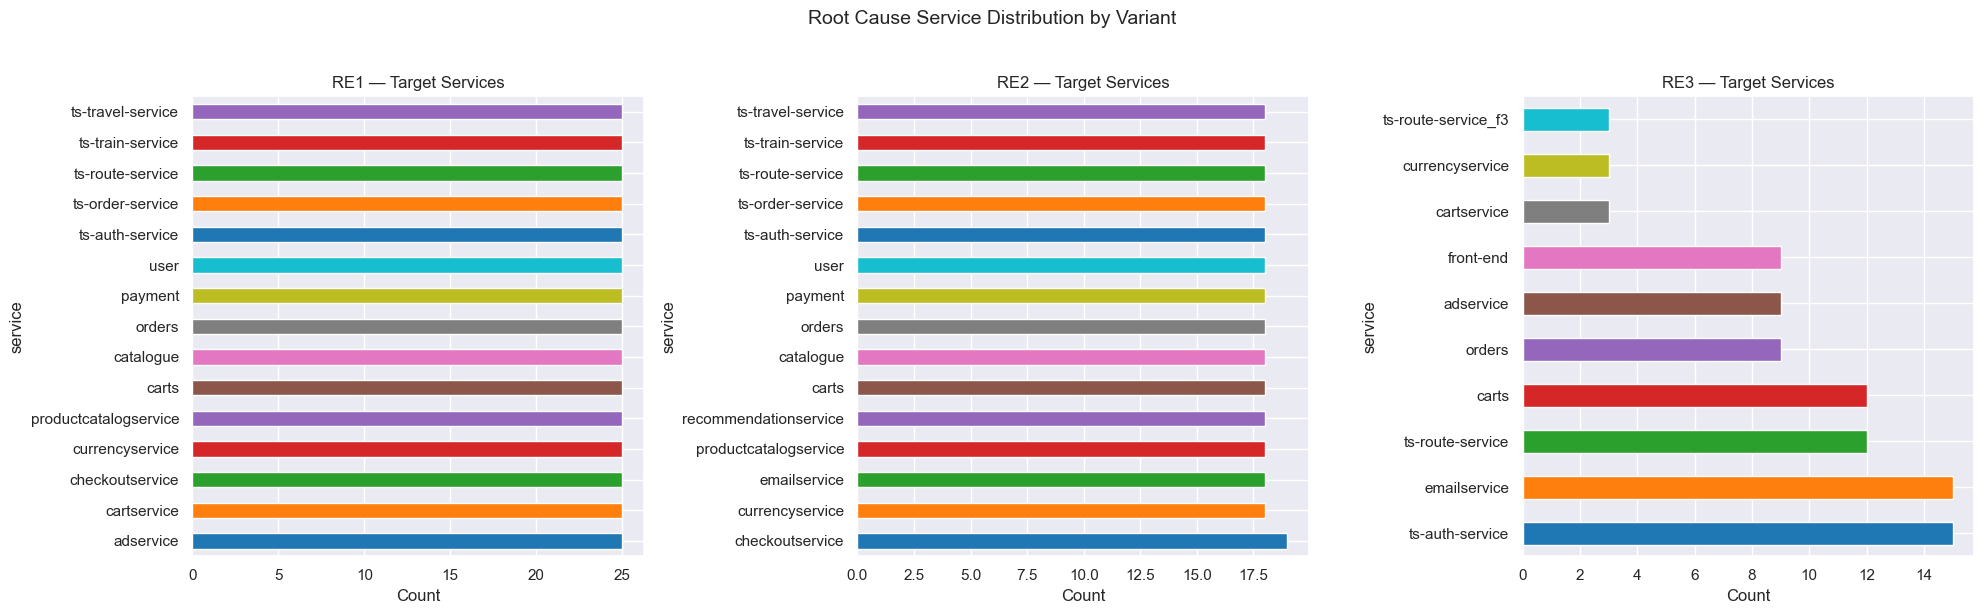


Fault Type × Service cross-tabulation (RE2 — primary comparison track):
fault_type             cpu  delay  disk  loss  mem  socket
service                                                   
carts                    3      3     3     3    3       3
catalogue                3      3     3     3    3       3
checkoutservice          4      3     3     3    3       3
currencyservice          3      3     3     3    3       3
emailservice             3      3     3     3    3       3
orders                   3      3     3     3    3       3
payment                  3      3     3     3    3       3
productcatalogservice    3      3     3     3    3       3
recommendationservice    3      3     3     3    3       3
ts-auth-service          3      3     3     3    3       3
ts-order-service         3      3     3     3    3       3
ts-route-service         3      3     3     3    3       3
ts-train-service         3      3     3     3    3       3
ts-travel-service        3      3     3   

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, variant in zip(axes, ["RE1", "RE2", "RE3"]):
    vdf = case_df[case_df["variant"] == variant]
    svc_counts = vdf["service"].value_counts()
    svc_counts.plot.barh(ax=ax, color=sns.color_palette("tab10", len(svc_counts)))
    ax.set_title(f"{variant} — Target Services", fontsize=12)
    ax.set_xlabel("Count")

plt.suptitle("Root Cause Service Distribution by Variant", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Cross-tabulation: fault type x service
print("\nFault Type × Service cross-tabulation (RE2 — primary comparison track):")
re2_xtab = pd.crosstab(
    case_df[case_df["variant"] == "RE2"]["service"],
    case_df[case_df["variant"] == "RE2"]["fault_type"]
)
print(re2_xtab.to_string())

## Metric Column Naming Analysis

Collect all unique column names from metric files across systems to understand the normalization work needed for the `RCAEvalDataAdapter`.

In [6]:
column_sets = {}

for variant in VARIANTS:
    variant_dir = RCAEVAL_DIR / variant
    for system_dir in sorted(variant_dir.iterdir()):
        if not system_dir.is_dir():
            continue
        system_code = system_dir.name.split("-")[-1]
        key = f"{variant.upper()}-{system_code}"

        # Read columns from the first available case
        for inject_file in system_dir.rglob("inject_time.txt"):
            case_dir = inject_file.parent
            # Try data.csv (RE1) then metrics.csv (RE2/RE3)
            for csv_name in ["data.csv", "metrics.csv"]:
                csv_path = case_dir / csv_name
                if csv_path.exists():
                    cols = pd.read_csv(csv_path, nrows=0).columns.tolist()
                    column_sets[key] = {
                        "file": csv_name,
                        "num_columns": len(cols),
                        "columns": cols,
                    }
                    break
            if key in column_sets:
                break

# Display summary
for key, info in sorted(column_sets.items()):
    print(f"\n{key} ({info['file']}, {info['num_columns']} columns):")
    # Show first 15 columns and last 5
    cols = info["columns"]
    for c in cols[:15]:
        print(f"  {c}")
    if len(cols) > 15:
        print(f"  ... ({len(cols) - 15} more)")


RE1-OB (data.csv, 51 columns):
  time
  adservice_cpu
  cartservice_cpu
  checkoutservice_cpu
  currencyservice_cpu
  emailservice_cpu
  frontend_cpu
  main_cpu
  paymentservice_cpu
  productcatalogservice_cpu
  recommendationservice_cpu
  redis_cpu
  shippingservice_cpu
  adservice_mem
  cartservice_mem
  ... (36 more)

RE1-SS (data.csv, 439 columns):
  time
  carts_container-cpu-system-seconds-total
  carts-db_container-cpu-system-seconds-total
  catalogue_container-cpu-system-seconds-total
  catalogue-db_container-cpu-system-seconds-total
  front-end_container-cpu-system-seconds-total
  orders_container-cpu-system-seconds-total
  orders-db_container-cpu-system-seconds-total
  payment_container-cpu-system-seconds-total
  queue-master_container-cpu-system-seconds-total
  rabbitmq_container-cpu-system-seconds-total
  rabbitmq-exporter_container-cpu-system-seconds-total
  session-db_container-cpu-system-seconds-total
  shipping_container-cpu-system-seconds-total
  user_container-cpu-sy

In [7]:
# Identify common metric name patterns
print("Column naming patterns by variant and system:")
print("=" * 60)

for key, info in sorted(column_sets.items()):
    cols = [c for c in info["columns"] if c != "time"]
    # Extract unique suffixes (metric types)
    suffixes = set()
    prefixes = set()
    for c in cols:
        parts = c.split("_", 1)
        if len(parts) == 2:
            prefixes.add(parts[0])
            suffixes.add(parts[1])

    print(f"\n{key}:")
    print(f"  Services ({len(prefixes)}): {sorted(prefixes)}")
    print(f"  Metric types ({len(suffixes)}): {sorted(suffixes)[:10]}{'...' if len(suffixes) > 10 else ''}")

Column naming patterns by variant and system:

RE1-OB:
  Services (14): ['PassthroughCluster', 'adservice', 'cartservice', 'checkoutservice', 'currencyservice', 'emailservice', 'frontend', 'frontend-external', 'main', 'paymentservice', 'productcatalogservice', 'recommendationservice', 'redis', 'shippingservice']
  Metric types (5): ['cpu', 'error', 'latency', 'load', 'mem']

RE1-SS:
  Services (23): ['192-168-10-83-9100', '192-168-22-131-9100', '192-168-56-14-9100', '192-168-60-79-9100', '192-168-90-135-9100', 'carts', 'carts-db', 'catalogue', 'catalogue-db', 'front', 'front-end', 'orders', 'orders-db', 'payment', 'queue', 'queue-master', 'rabbitmq', 'rabbitmq-exporter', 'session', 'session-db', 'shipping', 'user', 'user-db']
  Metric types (48): ['container-cpu-system-seconds-total', 'container-cpu-usage-seconds-total', 'container-cpu-user-seconds-total', 'container-fs-reads-bytes-total', 'container-fs-reads-total', 'container-fs-writes-bytes-total', 'container-fs-writes-total', 'cont

## Data Format Comparison Across Variants

Summary of data availability and format differences.

In [8]:
format_summary = []
for variant in ["RE1", "RE2", "RE3"]:
    vdf = case_df[case_df["variant"] == variant]
    format_summary.append({
        "Variant": variant,
        "Total Cases": len(vdf),
        "Systems": ", ".join(sorted(vdf["system"].unique())),
        "Fault Types": len(vdf["fault_type"].unique()),
        "Target Services": len(vdf["service"].unique()),
        "Has Metrics": vdf["has_data_csv"].any() or vdf["has_metrics_csv"].any(),
        "Has Logs": vdf["has_logs"].any(),
        "Has Traces": vdf["has_traces"].any(),
        "Metric File": "data.csv" if vdf["has_data_csv"].any() else "metrics.csv",
        "Avg Metric Columns": np.mean([
            column_sets.get(f"{variant}-{s}", {}).get("num_columns", 0)
            for s in sorted(vdf["system"].unique())
        ]),
    })

format_df = pd.DataFrame(format_summary)
print("Data Format Comparison:")
print()
display(format_df.set_index("Variant"))

Data Format Comparison:



,Total Cases,Systems,Fault Types,Target Services,Has Metrics,Has Logs,Has Traces,Metric File,Avg Metric Columns
Variant,,,,,,,,,
RE1,375,"OB, SS, TT",5,15,True,False,False,data.csv,578.666667
RE2,271,"OB, SS, TT",6,15,True,True,True,metrics.csv,813.000000
RE3,90,"OB, SS, TT",6,10,True,True,True,metrics.csv,733.666667


## Summary for Phase 3 Adapter Design

### Key Findings

**File Format Differences:**
- **RE1** uses `data.csv` with simple column naming: `{service}_{metric}` (e.g., `adservice_cpu`, `cartservice_mem`)
- **RE2/RE3** use `metrics.csv` with container-metric naming: `{service}_{container-metric-name}` (e.g., `adservice_container-cpu-usage-seconds-total`)
- RE2/RE3 have ~8x more metric columns than RE1 due to finer-grained container metrics

**Service Naming Across Systems:**
- **OB (Online Boutique):** `adservice`, `cartservice`, `checkoutservice`, `currencyservice`, etc.
- **SS (Sock Shop):** `carts`, `catalogue`, `orders`, `payment`, `user`, etc.
- **TT (Train Ticket):** `ts-auth-service`, `ts-order-service`, `ts-route-service`, etc.

**Adapter Requirements (`RCAEvalDataAdapter`):**
1. Handle both `data.csv` (RE1) and `metrics.csv` (RE2/RE3) formats
2. Normalize service names across systems to a common format
3. Extract fault type and target service from directory names
4. Parse `inject_time.txt` as Unix timestamp
5. For RE2/RE3: optionally load `logs.csv` and `traces.csv`
6. Handle different column counts across systems (49–418 metric columns)

**Case Count Summary:**
- RE1: 375 cases (125 per system × 3 systems)
- RE2: 271 cases (90–91 per system × 3 systems)
- RE3: 90 cases (30 per system × 3 systems)
- **Total: 736 cases**